In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skills: ast.literal_eval(skills) if not pd.isna(skills) else skills)

## .explode() method for dealing with lists

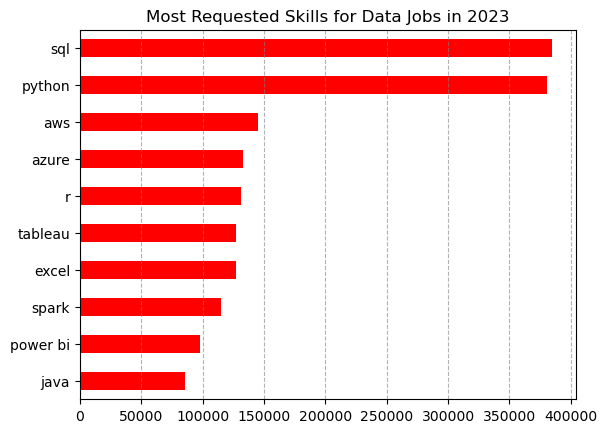

In [38]:
# exploding into simple rows with no aggregation

(
    df["job_skills"]
        .explode()
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh", color="red")
)
plt.ylabel("")
plt.xlabel("")
plt.title("Most Requested Skills for Data Jobs in 2023")
plt.grid(True, axis="x", color="gray", alpha=0.6, linestyle="--")
plt.show()

In [64]:
# aggregating by skills and job titles

filtered_df = df.loc[
    df["job_skills"].notna(),
    ["job_title_short", "job_skills"]
].explode("job_skills")

filtered_df


,job_title_short,job_skills
1,Data Analyst,r
1,Data Analyst,python
1,Data Analyst,sql
1,Data Analyst,nosql
1,Data Analyst,power bi
...,...,...
785739,Data Engineer,kafka
785739,Data Engineer,kubernetes
785739,Data Engineer,docker
785740,Software Engineer,aws


In [65]:
filtered_df = filtered_df.groupby(["job_title_short", "job_skills"]).agg(
    skills_count=("job_skills", "size")
).reset_index()

filtered_df

,job_title_short,job_skills,skills_count
0,Business Analyst,airflow,318
1,Business Analyst,airtable,17
2,Business Analyst,alteryx,1078
3,Business Analyst,angular,87
4,Business Analyst,ansible,120
...,...,...,...
2251,Software Engineer,wrike,4
2252,Software Engineer,wsl,13
2253,Software Engineer,xamarin,35
2254,Software Engineer,yarn,145


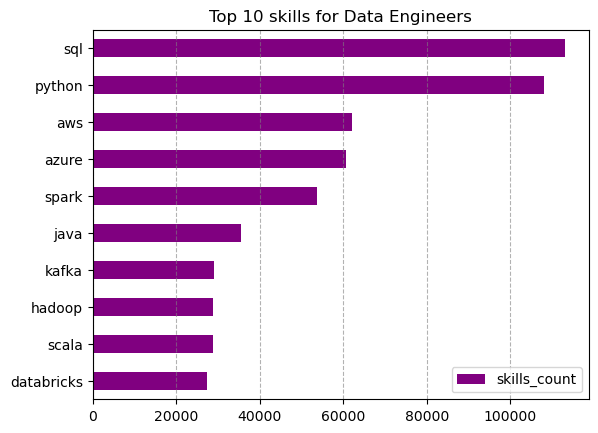

In [98]:
job_title = "Data Engineer"
top_skills = 10

final_filtered_df = filtered_df.loc[
    filtered_df["job_title_short"] == job_title,
    :
].sort_values(by="skills_count", ascending=False).head(top_skills)

final_filtered_df.plot(kind="barh", x="job_skills", y="skills_count", color="purple")
plt.gca().invert_yaxis()
plt.ylabel("")
plt.title(f"Top {top_skills} skills for {job_title}s")
plt.grid(True, axis="x", color="gray", alpha=0.6, linestyle="--")
plt.show()